In [2]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RESULTS_DIR = Path("../results")

In [3]:
records = []
for json_file in RESULTS_DIR.rglob("*.json"):
    data = json.loads(json_file.read_text())
    for item in data:
        records.append(
            {
                "model": item["model"],
                "task": item["task"],
                "condition": item["condition"],
                "query": item["stimulus"]["query"],
                "expected": item["stimulus"]["expected"],
                "few_shot_examples": item["stimulus"]["few_shot_examples"],
                "metadata": item["stimulus"]["metadata"],
                "response_text": item["response"]["text"],
                "token_logprobs": item["response"]["token_logprobs"],
                "correct": item["score"]["correct"],
                "logprob_correct": item["score"]["logprob_correct"],
                "timestamp": item["timestamp"],
            }
        )

df = pd.DataFrame(records)
print(
    f"Loaded {len(df)} trials from {df['model'].nunique() if len(df) > 0 else 0} models"
)
df.head()

Loaded 314 trials from 1 models


,model,task,condition,query,expected,few_shot_examples,metadata,response_text,token_logprobs,correct,logprob_correct,timestamp
0,EleutherAI/pythia-70m,rules,few_shot,ba po,po,"[[ga ti, ti], [li na, na], [ta da, da]]","{'rule': 'ABB', 'source': 'Marcus 1999', 'note...","śwowie, kakuru..., tu tu ti ti ti ti ti ti--li...","[-6.972419261932373, -2.6576995849609375, -9.2...",False,-5.967631,2026-03-25T18:09:31.772225Z
1,EleutherAI/pythia-70m,rules,few_shot,ba po,ba,"[[ga ti, ga], [li na, li], [ta da, ta]]","{'rule': 'ABA', 'source': 'Marcus 1999', 'note...",od\nte s &o\nli\nin t'a le cŔ ầm potupt\nty il...,"[-7.844737529754639, -1.474900484085083, -4.10...",False,-6.842824,2026-03-25T18:09:31.889009Z
2,EleutherAI/pythia-70m,rules,zero_shot,ba po,po,"[[ga ti, ti], [li na, na], [ta da, da]]","{'rule': 'ABB', 'source': 'Marcus 1999', 'note...","o-ingetikuuta. Maatalu tuha pervivorna pesca, ...","[-5.190425395965576, -2.9603939056396484, -4.1...",False,-6.186333,2026-03-25T18:09:31.546037Z
3,EleutherAI/pythia-70m,rules,zero_shot,ba po,ba,"[[ga ti, ga], [li na, li], [ta da, ta]]","{'rule': 'ABA', 'source': 'Marcus 1999', 'note...","iya du yare, silci dus la' repairs.22: ymeram...","[-2.190425395965576, -6.9052934646606445, -7.6...",False,-8.186333,2026-03-25T18:09:31.657022Z
4,EleutherAI/pythia-70m,matrix,zero_shot,[6] [6] [6]\n[1] [1] [1]\n[3] [3] [,3,"[[[0] [0] [0]\n[3] [3] [3]\n[2] [2] [, 2], [[3...","{'rule_type': 'row_constant', 'perm_invariant'...",3] [1]\n[3] [4] [4] [11]\n[5];\n\nCode 8.1) in...,"[-0.7973308563232422, -0.02244754135608673, -0...",True,-1.441716,2026-03-25T18:09:33.002622Z


In [9]:
if df.empty:
    print("No results loaded yet.")
else:
    accuracy = (
        df.groupby(["model", "task", "condition"])["correct"]
        .mean()
        .mul(100)
        .round(1)
        .unstack("condition")
        .reset_index()
    )
    accuracy.columns.name = None
    print(accuracy.to_string(index=False))

                model         task  few_shot  zero_shot
EleutherAI/pythia-70m hierarchical       0.0        0.0
EleutherAI/pythia-70m       matrix      10.6        8.6
EleutherAI/pythia-70m        rules       0.0        0.0


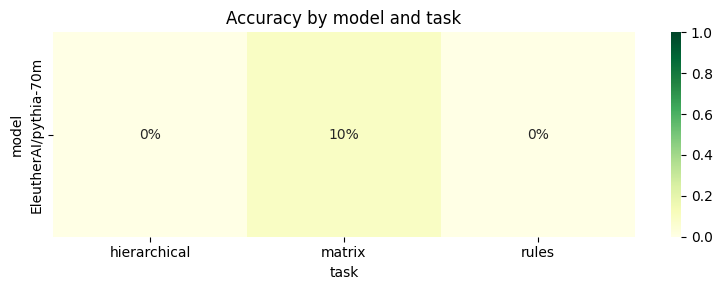

In [10]:
if df.empty:
    print("No results loaded yet.")
else:
    pivot = df.groupby(["model", "task"])["correct"].mean().unstack("task")
    plt.figure(figsize=(8, max(3, len(pivot) * 0.6)))
    sns.heatmap(pivot, annot=True, fmt=".0%", cmap="YlGn", vmin=0, vmax=1)
    plt.title("Accuracy by model and task")
    plt.tight_layout()
    plt.show()

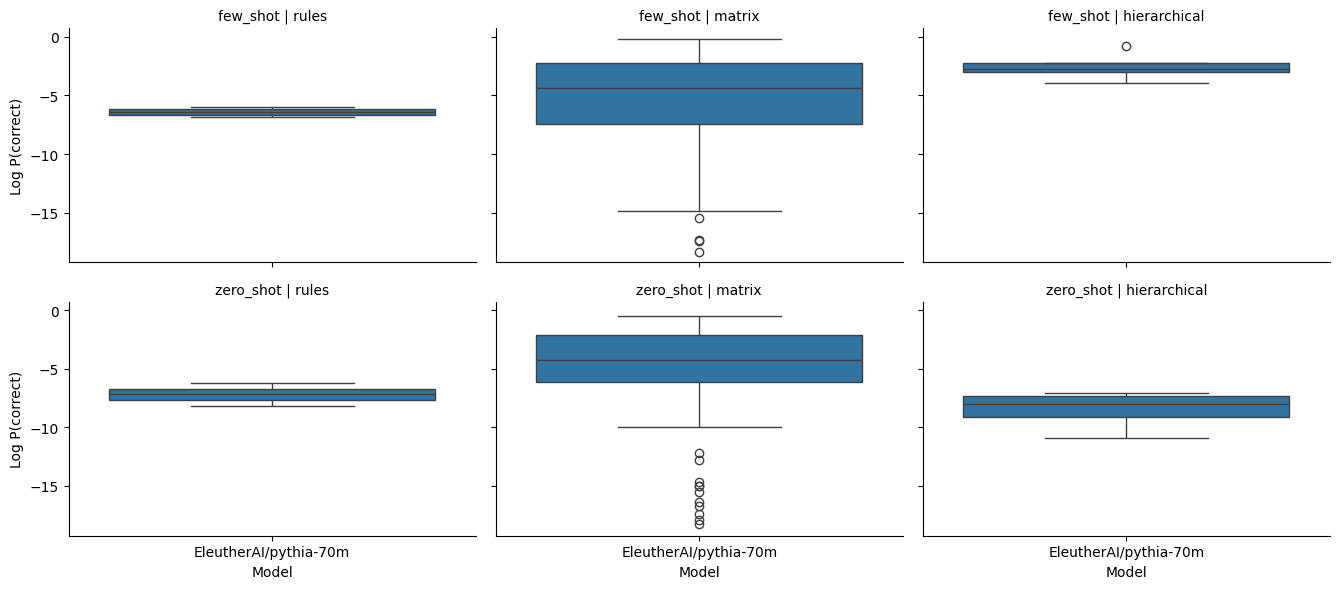

In [11]:
if df.empty or df["logprob_correct"].isna().all():
    print("No log prob data available yet.")
else:
    lp_df = df.dropna(subset=["logprob_correct"])
    g = sns.FacetGrid(lp_df, col="task", row="condition", height=3, aspect=1.5)
    g.map_dataframe(sns.boxplot, x="model", y="logprob_correct")
    g.set_axis_labels("Model", "Log P(correct)")
    g.set_titles("{row_name} | {col_name}")
    plt.tight_layout()
    plt.show()

In [8]:
if df.empty:
    print("No results loaded yet.")
else:
    df["rule"] = df["metadata"].apply(
        lambda m: m.get("rule") or m.get("pattern", "unknown")
    )
    rule_acc = (
        df.groupby(["task", "rule", "condition"])["correct"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "accuracy", "count": "n"})
        .reset_index()
    )
    rule_acc["accuracy"] = rule_acc["accuracy"].mul(100).round(1)
    print(rule_acc.to_string(index=False))

        task                rule condition  accuracy   n
hierarchical different-different  few_shot       0.0   1
hierarchical different-different zero_shot       0.0   1
hierarchical      same-different  few_shot       0.0   2
hierarchical      same-different zero_shot       0.0   2
hierarchical           same-same  few_shot       0.0   1
hierarchical           same-same zero_shot       0.0   1
      matrix             unknown  few_shot      10.6 151
      matrix             unknown zero_shot       8.6 151
       rules                 ABA  few_shot       0.0   1
       rules                 ABA zero_shot       0.0   1
       rules                 ABB  few_shot       0.0   1
       rules                 ABB zero_shot       0.0   1
